In [1]:
import os, re, sys, glob, json, shutil, subprocess, tempfile
import numpy as np, cv2, pandas as pd
from scipy.ndimage import median_filter
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PDF        = "../19series.pdf"
PAGES      = [1, 2, 3, 20, 70]
WORK       = "work"
OUT        = "outputs"
GRID_FT    = 10.0
INK_THRESH = 200
ELEV_LABEL_GUTTER = 134
DESPIKE_WIN, DESPIKE_PX = 9, 4.0
BURIED_RUN_FT, BURIED_DEPTH_FT = 25.0, 3.5
GAP_REFINE_FT, GAP_TOL_PX = 3.0, 7.0
GAP_WARN_FT = 5.0

os.makedirs(WORK, exist_ok=True); os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("cv2", cv2.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)
print("poppler:", "OK" if shutil.which("pdfimages") else "MISSING  (apt-get install poppler-utils)")
print("tesseract:", "OK" if shutil.which("tesseract") else "MISSING (datum will fall back to manual)")

cv2 5.0.0 | numpy 2.5.1 | pandas 3.0.5
poppler: OK
tesseract: OK


In [2]:
def extract_pages(pdf=PDF, pages=PAGES, work=WORK):
    """The PDF is a scan: every page is ONE embedded JPEG at its native size.
    pdfimages pulls that JPEG out losslessly - no resampling, no interpolation,
    which matters because every measurement below is made in pixels."""
    out = {}
    for p in pages:
        dst = os.path.join(work, f"page_{p:03d}.png")
        if not os.path.exists(dst):
            with tempfile.TemporaryDirectory() as td:
                subprocess.run(["pdfimages", "-f", str(p), "-l", str(p), "-png", pdf,
                                os.path.join(td, "im")], check=True)
                got = sorted(glob.glob(os.path.join(td, "im*.png")))
                if not got:
                    subprocess.run(["pdftoppm", "-f", str(p), "-l", str(p), "-r", "150",
                                    "-png", pdf, os.path.join(td, "im")], check=True)
                    got = sorted(glob.glob(os.path.join(td, "im*.png")))
                shutil.copy(got[0], dst)
        out[p] = dst
    return out

PAGE_FILES = extract_pages()
for p, f in PAGE_FILES.items():
    im = cv2.imread(f, 0)
    print(f"page {p}: {f}  {im.shape[1]} x {im.shape[0]} px   ink {(im<INK_THRESH).mean()*100:.2f}%")

page 1: work/page_001.png  4896 x 717 px   ink 4.92%
page 2: work/page_002.png  4896 x 721 px   ink 4.21%


page 3: work/page_003.png  4896 x 1212 px   ink 5.05%
page 20: work/page_020.png  4896 x 577 px   ink 5.07%


page 70: work/page_070.png  4896 x 924 px   ink 5.70%


In [3]:
def runs1d(a, tol=3):
    """Group a sorted index array into (start, end) runs, merging gaps <= tol."""
    if len(a) == 0: return []
    out, s, p = [], a[0], a[0]
    for v in a[1:]:
        if v - p > tol: out.append((int(s), int(p))); s = v
        p = v
    out.append((int(s), int(p)))
    return out

def dilate1d(v, k):
    """Binary dilation of a 1-D boolean vector by k samples each way."""
    out = v.copy()
    for s in range(1, k + 1):
        out[:-s] |= v[s:]; out[s:] |= v[:-s]
    return out

def detect_lattice(ink, frac=0.45):
    """Grid lines are the only strokes that run (almost) the full height / width.
    Returns run-groups of columns and rows that qualify."""
    H, W = ink.shape
    return (runs1d(np.where(ink.sum(0) > frac * H)[0]),
            runs1d(np.where(ink.sum(1) > frac * W)[0]))

def strip_grid(ink, V, H_, bridge=5):
    """Delete the lattice, then SURGICALLY repair the curves it was crossing.

    Naively zeroing a grid column also punches a hole through every data curve
    that crossed it, shattering each curve into ~140 px fragments.  So for each
    deleted band we re-connect only those rows where ink exists on BOTH sides
    within +-`bridge` px -- i.e. we restore continuity without restoring the grid."""
    m = ink.copy()
    for s, e in V:  m[:, max(0, s - 1):e + 2] = 0
    for s, e in H_: m[max(0, s - 1):e + 2, :] = 0
    for s, e in V:
        a, b = s - 2, e + 2
        if a < 0 or b >= m.shape[1]: continue
        both = dilate1d(m[:, a].astype(bool), bridge) & dilate1d(m[:, b].astype(bool), bridge)
        m[:, a + 1:b] |= both[:, None].astype(np.uint8)
    for s, e in H_:
        a, b = s - 2, e + 2
        if a < 0 or b >= m.shape[0]: continue
        both = dilate1d(m[a, :].astype(bool), bridge) & dilate1d(m[b, :].astype(bool), bridge)
        m[a + 1:b, :] |= both[None, :].astype(np.uint8)
    return m

def plot_axes(ink, V, r0, r1, pitch):
    """The two verticals bounding the plot are the ones carrying elevation tick
    stubs along the WHOLE height.  Scoring by ink volume alone gets fooled by a
    steep embankment; scoring by *vertical coverage* does not."""
    nb = max(4, int((r1 - r0) / (pitch / 5)))
    edges = np.linspace(r0, r1, nb + 1).astype(int)
    cov = lambda b: sum(1 for a, z in zip(edges[:-1], edges[1:]) if b[a:z].any()) / nb
    sc = []
    for s, e in V:
        if e - s + 1 > 4: continue
        sc.append(((s + e) / 2.0,
                   cov(ink[:, max(0, s - 13):max(0, s - 2)].max(1)),
                   cov(ink[:, e + 3:e + 14].max(1))))
    mid = np.median([c for c, _, _ in sc])
    return (max([x for x in sc if x[0] < mid], key=lambda t: t[2])[0],
            max([x for x in sc if x[0] > mid], key=lambda t: t[1])[0])

def _gutter_ocr(m, x0, y0, y1, psm, scale, ndig=3):
    crop = 255 - m[y0:y1, x0:x0 + ELEV_LABEL_GUTTER] * 255
    if (crop < 128).sum() < 20: return []
    crop = cv2.resize(crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    crop = cv2.copyMakeBorder(crop, 40, 40, 40, 40, cv2.BORDER_CONSTANT, value=255)
    f = tempfile.mktemp(suffix=".png"); cv2.imwrite(f, crop)
    o = subprocess.run(["tesseract", f, "stdout", "tsv", "--psm", psm,
                        "-c", "tessedit_char_whitelist=0123456789"],
                       capture_output=True, text=True)
    os.unlink(f)
    out = []
    for ln in o.stdout.splitlines()[1:]:
        fl = ln.split("\t")
        t = (fl[11] or "").strip() if len(fl) >= 12 else ""
        if re.fullmatch(r"\d{%d}" % ndig, t) and int(t) % 10 == 0:
            out.append((y0 + (int(fl[7]) + int(fl[9]) / 2 - 40) / scale, int(t)))
    return out

def read_elev_labels(ink, V, H_, right_axis, lat_rows):
    """Read the RIGHT-hand elevation gutter (the left gutter's leading digit is
    overprinted by the sheet frame).  Two readers are pooled, because neither is
    reliable alone on a 1990s scan: one pass over the whole strip, and one tight
    crop per grid line.  Wrong readings are thrown out by consensus, not trusted."""
    if not shutil.which("tesseract"): return []
    m = ink.copy()
    for s_, e in V:  m[:, max(0, s_ - 1):e + 2] = 0
    for s_, e in H_: m[max(0, s_ - 1):e + 2, :] = 0
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    x0 = int(right_axis) + 6
    pool = []
    for sc in (6, 8):
        pool += _gutter_ocr(m, x0, 0, m.shape[0], "6", sc)
    for r in lat_rows:
        a, b = int(r - 26), int(r + 26)
        if a < 0 or b > m.shape[0]: continue
        for psm in ("7", "8", "13"):
            for sc in (6, 8):
                pool += _gutter_ocr(m, x0, a, b, psm, sc)
    return pool

def fit_datum(pool, lat_rows, pitch):
    """Every label votes for one constant  C = elev + row / px_per_ft.  Snap each
    label to the grid line it annotates first -- OCR returns the row of the text,
    which sits ~15 px above that line and is worth 1.05 ft of bias if believed.
    Then keep the largest agreeing block and average it (RANSAC in one dimension)."""
    if not pool: return None, 0, 0
    ppf = pitch / GRID_FT; lat = np.asarray(lat_rows); votes = []
    for r, e in pool:
        j = int(np.argmin(abs(lat - r)))
        if abs(lat[j] - r) < pitch * 0.35: votes.append(e + lat[j] / ppf)
    if not votes: return None, 0, len(pool)
    best = max(votes, key=lambda c: sum(1 for k in votes if abs(k - c) < 0.5))
    inl = [c for c in votes if abs(c - best) < 0.5]
    if len(inl) < 2: return None, len(inl), len(votes)
    return float(np.mean(inl)), len(inl), len(votes)

def denoise(roi):
    """Drop annotation glyphs, traffic arrows and survey specks.  Discriminator is
    BOX FILL RATIO: a digit fills ~0.3-0.6 of its bounding box, a 2 px line
    through the same box fills < 0.15."""
    n, lab, st, _ = cv2.connectedComponentsWithStats(roi, 8)
    keep = np.zeros_like(roi); dropped = 0
    for k in range(1, n):
        x, y, w, h, a = st[k]; f = a / (w * h)
        if (8 <= w <= 70 and 10 <= h <= 55 and f >= 0.30) \
           or (a > 700 and f >= 0.35) or (a <= 12 and w <= 7 and h <= 7):
            dropped += 1; continue
        keep[lab == k] = 1
    return keep, dropped

def split_dash_solid(mask):
    """Existing ground is DASHED, the proposed template is SOLID.  Estimate the
    dash length from the component-width distribution and cut at 3x the median,
    so the threshold adapts to scan resolution instead of being hard-coded."""
    n, lab, st, _ = cv2.connectedComponentsWithStats(mask, 8)
    ws = np.array([st[k, cv2.CC_STAT_WIDTH] for k in range(1, n)])
    dash_w = float(np.median(ws)) if len(ws) else 12.0
    thr = max(40.0, 3.0 * dash_w)
    dash, solid = np.zeros_like(mask), np.zeros_like(mask)
    for k in range(1, n):
        w, h = st[k, cv2.CC_STAT_WIDTH], st[k, cv2.CC_STAT_HEIGHT]
        (solid if max(w, h) >= thr else dash)[lab == k] = 1
    return dash, solid, thr, dash_w

def candidates(mask, max_run=30):
    """Per column, the mid-point of every vertical ink run = a curve observation."""
    out = []
    for x in range(mask.shape[1]):
        col = np.where(mask[:, x])[0]; c = []
        for s, e in runs1d(col, tol=2):
            if e - s + 1 <= max_run: c.append((s + e) / 2.0)
            else: c += [float(s), float(e)]
        out.append(c)
    return out

def best_path(cands, reward=3.0, win=260, slope=0.6, slack=8.0, gap_pen=0.04):
    """Max-scoring chain through the candidate points (Viterbi over a DAG).

    A greedy left-to-right tracker breaks at the first long dash gap and then
    coasts away from the curve.  Scoring globally -- +reward per point used,
    -|dy| for roughness, -gap_pen per skipped column -- recovers the whole
    surface including the stretch hidden behind the proposed template."""
    pts = [(x, y) for x, c in enumerate(cands) for y in c]
    if not pts: return {}
    n = len(pts)
    xs = np.array([p[0] for p in pts]); ys = np.array([p[1] for p in pts])
    score = np.full(n, reward); prev = np.full(n, -1); start = 0
    for i in range(n):
        xi, yi = xs[i], ys[i]
        while xs[start] < xi - win: start += 1
        for j in range(start, i):
            dx = xi - xs[j]
            if dx <= 0: continue
            dy = abs(yi - ys[j])
            if dy > slope * dx + slack: continue
            s = score[j] + reward - dy - gap_pen * (dx - 1)
            if s > score[i]: score[i] = s; prev[i] = j
    k = int(np.argmax(score)); path = []
    while k >= 0: path.append(k); k = prev[k]
    return {int(xs[i]): float(ys[i]) for i in reversed(path)}

def snap_top(mask, chain, rad=9):
    """The template is drawn as a thin box (surface + pavement structure), so the
    finished surface is the TOPMOST stroke -- and we want that stroke's CENTRE.
    Taking its upper edge biases the whole surface up by half a stroke width,
    which is ~0.2 ft here and shows up directly as a fill/cut error."""
    out = {}
    for x, y in chain.items():
        lo, hi = max(0, int(y) - rad), min(mask.shape[0], int(y) + rad + 1)
        w = np.where(mask[lo:hi, x])[0]
        if len(w) == 0: out[x] = y; continue
        a, b = runs1d(w, tol=1)[0]
        out[x] = float(lo + (a + b) / 2.0)
    return out

def despike(y, win=None, thresh_px=None):
    """Reject outliers only -- do NOT smooth.  Leader lines, witness ticks and
    dimension arrows that survived the glyph filter show up as isolated jumps of
    5-8 px; genuine break-points (ditch invert, catch point, shoulder hinge) must
    come through untouched, so flagged samples are replaced by interpolation from
    their good neighbours rather than by a filtered value."""
    win = win or DESPIKE_WIN; thresh_px = thresh_px or DESPIKE_PX
    ok = ~np.isnan(y); idx = np.where(ok)[0]
    if len(idx) < win: return y, 0
    v = y[idx].copy()
    bad = np.abs(v - median_filter(v, size=win, mode="nearest")) > thresh_px
    if bad.any() and (~bad).sum() >= 2:
        v[bad] = np.interp(idx[bad], idx[~bad], v[~bad])
    out = y.copy(); out[idx] = v
    return out, int(bad.sum())

def trim_buried_tail(x, gpx, dpx, ppf):
    """Temporary pipes and other buried services run on past the template's toe.
    They read as a LONG, DEEP run of 'proposed below existing' that reaches the
    end of the chain -- a graded cut always closes back onto the ground inside
    the template, so it never looks like this.  Measured on this drawing set:
    real ditch cuts are <= 19 ft long and <= 3 ft deep, the temporary pipe at
    station 21+00 is 45 ft long and 6 ft deep."""
    ov = ~np.isnan(gpx) & ~np.isnan(dpx)
    if ov.sum() < 10: return dpx, []
    c = np.where(ov)[0]; xx = x[c]
    d = (gpx[c] - dpx[c]) / ppf
    sign = np.sign(np.where(np.abs(d) < 0.10, 0, d))
    runs, i = [], 0
    while i < len(d):
        if sign[i] < 0:
            j = i
            while j < len(d) and sign[j] <= 0: j += 1
            runs.append((i, j - 1, xx[j - 1] - xx[i], float(-d[i:j].min())))
            i = j
        else: i += 1
    out = dpx.copy(); killed = []
    for a, b, L, dep in runs:
        if L < BURIED_RUN_FT or dep < BURIED_DEPTH_FT: continue
        if xx[-1] - xx[b] <= 2.0:
            out[c[a]:] = np.nan; killed.append(dict(side="right", x_from=round(float(xx[a]), 2),
                                                    x_to=round(float(xx[-1]), 2),
                                                    run_ft=round(float(L), 1), depth_ft=round(dep, 2)))
        elif xx[a] - xx[0] <= 2.0:
            out[:c[b] + 1] = np.nan; killed.append(dict(side="left", x_from=round(float(xx[0]), 2),
                                                        x_to=round(float(xx[b]), 2),
                                                        run_ft=round(float(L), 1), depth_ft=round(dep, 2)))
    return out, killed

def refine_gaps(chain, full_mask, ppf, min_gap_ft=None, tol_px=None):
    """Inside a long interpolation gap the surface's own dashes usually still
    exist -- they were simply absorbed into a solid component they touch, so the
    dash/solid split never offered them.  Re-hunt for ink near the interpolated
    path in the FULL mask and accept it when it is close enough to be the same
    surface.  This is a recall pass, not a smoother: it only ever adds points."""
    min_gap_ft = min_gap_ft or GAP_REFINE_FT; tol_px = tol_px or GAP_TOL_PX
    if len(chain) < 2: return chain, 0
    xs = np.array(sorted(chain)); ys = np.array([chain[x] for x in xs])
    add = {}
    for i in np.where(np.diff(xs)/ppf > min_gap_ft)[0]:
        a, b, ya, yb = xs[i], xs[i+1], ys[i], ys[i+1]
        for x in range(a+1, b):
            yp = ya + (yb-ya)*(x-a)/(b-a)
            col = np.where(full_mask[:, x])[0]
            if not len(col): continue
            best = min(((s_+e)/2 for s_, e in runs1d(col, tol=2)), key=lambda c: abs(c-yp))
            if abs(best-yp) <= tol_px: add[x] = best
    out = dict(chain); out.update(add)
    return out, len(add)

def interp_spans(chain, W, ppf, warn_ft=None):
    """Boolean per column: True where the surface is only a straight-line guess
    across a gap wider than `warn_ft`.  Area computed there is not supported by
    ink and is reported separately rather than quietly folded into the total."""
    warn_ft = warn_ft or GAP_WARN_FT
    m = np.zeros(W, bool)
    if len(chain) < 2: return m, 0.0
    xs = np.array(sorted(chain)); d = np.diff(xs)/ppf
    for i in np.where(d > warn_ft)[0]: m[xs[i]:xs[i+1]+1] = True
    return m, float(d.max()) if len(d) else 0.0

def densify(chain, W):
    """Chain -> dense per-column array, linearly interpolated, NaN outside."""
    g = np.full(W, np.nan)
    if not chain: return g
    xs = np.array(sorted(chain)); ys = np.array([chain[x] for x in xs])
    grid = np.arange(W); m = (grid >= xs[0]) & (grid <= xs[-1])
    g[m] = np.interp(grid[m], xs, ys)
    return g

class Section:
    """Everything measured off one cross-section sheet, in engineering units."""
    def __init__(self, page, path):
        self.page, self.path = page, path
        g = cv2.imread(path, 0); self.gray = g
        ink = (g < INK_THRESH).astype(np.uint8); self.ink = ink

        V, H_ = detect_lattice(ink)
        lat = [(s + e) / 2 for s, e in H_]
        self.pitch = float(np.median(np.diff(lat)))
        self.lat_rows = lat
        self.Lx, self.Rx = plot_axes(ink, V, H_[0][1] + 3, H_[-1][0] - 3, self.pitch)

        self.span_ft = round((self.Rx - self.Lx) / (self.pitch / GRID_FT) / 10) * 10
        self.ppf     = (self.Rx - self.Lx) / self.span_ft
        self.cx      = (self.Lx + self.Rx) / 2.0

        C, ni, nt = fit_datum(read_elev_labels(ink, V, H_, self.Rx, lat), lat, self.pitch)
        self.ocr_inliers, self.ocr_total = ni, nt
        if C is None:
            C = self.pitch * len(lat) / self.ppf
            self.datum_source = "relative (no datum recovered - elevations are not AMSL)"
        else:
            self.datum_source = f"OCR consensus {ni}/{nt}"
        self.datum = C

        clean = strip_grid(ink, V, H_)
        top = H_[0][0] - 1 if H_[0][0] > 10 else H_[0][1] + 2
        bot = H_[-1][0] - 42
        self.rx0, self.ry0 = int(self.Lx) + 16, max(0, top)
        roi = clean[self.ry0:bot, self.rx0:int(self.Rx) - 16]
        self.roi, self.dropped = denoise(roi)
        self.dash, self.solid, self.dash_thr, self.dash_w = split_dash_solid(self.roi)

        self.H, self.W = self.roi.shape
        self.ground_px = best_path(candidates(self.dash))
        self.design_px = snap_top(self.solid, best_path(candidates(self.solid)))
        self.ground_px, self.n_refined_g = refine_gaps(self.ground_px, self.roi, self.ppf)
        self.design_px, self.n_refined_d = refine_gaps(self.design_px, self.solid, self.ppf)
        self.g_interp, self.max_gap_g = interp_spans(self.ground_px, self.W, self.ppf)
        self.d_interp, self.max_gap_d = interp_spans(self.design_px, self.W, self.ppf)
        self.G, self.n_spike_g = despike(densify(self.ground_px, self.W))
        self.D, self.n_spike_d = despike(densify(self.design_px, self.W))
        self.D, self.trimmed = trim_buried_tail(self.x_ft(np.arange(self.W)),
                                                self.G, self.D, self.ppf)

    def x_ft(self, col):  return (self.rx0 + np.asarray(col, float) - self.cx) / self.ppf
    def col_of(self, xft): return np.asarray(xft, float) * self.ppf + self.cx - self.rx0
    def elev(self, row):  return self.datum - (self.ry0 + np.asarray(row, float)) / self.ppf
    def row_of(self, e):  return (self.datum - np.asarray(e, float)) * self.ppf - self.ry0

    @property
    def x(self):      return self.x_ft(np.arange(self.W))
    @property
    def ground(self): return self.elev(self.G)
    @property
    def design(self): return self.elev(self.D)
    @property
    def unsupported(self):
        """Columns where either surface is a guess across a wide gap."""
        return self.g_interp | self.d_interp

    @property
    def overlap(self):
        """Columns where BOTH surfaces exist - the only place an area is defined."""
        return ~np.isnan(self.G) & ~np.isnan(self.D)

    def summary(self):
        ov = self.overlap; xs = self.x[ov]
        return dict(page=self.page, px_per_ft=round(self.ppf, 4),
                    span_ft=self.span_ft, datum=round(self.datum, 2),
                    datum_src=self.datum_source,
                    ground_from=round(self.x[~np.isnan(self.G)].min(), 1),
                    ground_to=round(self.x[~np.isnan(self.G)].max(), 1),
                    design_from=round(xs.min(), 2) if ov.any() else None,
                    design_to=round(xs.max(), 2) if ov.any() else None,
                    glyphs_removed=self.dropped,
                    spikes_g=self.n_spike_g, spikes_d=self.n_spike_d,
                    max_gap_g_ft=round(self.max_gap_g, 1), max_gap_d_ft=round(self.max_gap_d, 1),
                    trimmed=len(self.trimmed))

In [4]:
SEC = {p: Section(p, f) for p, f in PAGE_FILES.items()}
display(pd.DataFrame([s.summary() for s in SEC.values()]).set_index("page"))

,px_per_ft,span_ft,datum,datum_src,ground_from,ground_to,design_from,design_to,glyphs_removed,spikes_g,spikes_d,max_gap_g_ft,max_gap_d_ft,trimmed
page,,,,,,,,,,,,,,
1,14.3964,280,688.08,OCR consensus 10/10,-117.0,107.3,-19.21,-10.94,56,0,0,2.7,0.3,0
2,14.3964,280,688.09,OCR consensus 13/16,-114.6,108.0,-49.84,-10.59,65,1,3,2.9,0.3,0
3,14.3964,280,722.22,OCR consensus 10/16,-111.5,116.2,-50.95,-9.20,69,0,0,3.3,0.3,0
20,14.3964,280,668.09,OCR consensus 5/8,-124.4,138.4,-67.00,26.78,77,0,19,2.6,0.3,1
70,14.3967,300,682.22,OCR consensus 20/27,-148.9,148.4,-59.84,12.82,79,8,7,8.8,0.5,0


In [5]:
def rdp(P, eps):
    """Douglas-Peucker on an (N,2) polyline, in engineering units."""
    P = np.asarray(P, float)
    if len(P) < 3: return P
    a, b = P[0], P[-1]; ab = b - a; L = float(np.hypot(*ab)); v = P - a
    d = np.abs(ab[0]*v[:, 1] - ab[1]*v[:, 0]) / L if L > 0 else np.hypot(v[:, 0], v[:, 1])
    i = int(np.argmax(d))
    if d[i] <= eps: return np.vstack([a, b])
    return np.vstack([rdp(P[:i+1], eps)[:-1], rdp(P[i:], eps)])

def merge_short(V, min_len=1.0):
    """Drop vertices that create segments shorter than `min_len` ft — those are
    annotation ticks and dash-boundary jitter, not design break-points."""
    V = np.asarray(V, float)
    while len(V) > 2:
        seg = np.hypot(*np.diff(V, axis=0).T)
        k = int(np.argmin(seg))
        if seg[k] >= min_len: break
        V = np.delete(V, k+1 if k+1 < len(V)-1 else k, axis=0)
    return V

def polyline(s, which="design", eps=0.10, min_len=2.5):
    arr = s.D if which == "design" else s.G
    ok = ~np.isnan(arr); cols = np.where(ok)[0]
    P = np.column_stack([s.x_ft(cols), s.elev(arr[cols])])
    return merge_short(rdp(P, eps), min_len)

def segment_table(V, page, which):
    rows = []
    for k in range(1, len(V)):
        dx, dy = V[k, 0]-V[k-1, 0], V[k, 1]-V[k-1, 1]
        rows.append(dict(page=page, curve=which, seg=k,
                         x_from=round(V[k-1, 0], 2), x_to=round(V[k, 0], 2),
                         elev_from=round(V[k-1, 1], 2), elev_to=round(V[k, 1], 2),
                         length_ft=round(float(np.hypot(dx, dy)), 2),
                         slope_pct=round(dy/dx*100, 2),
                         ratio=(f"{abs(dx/dy):.2f}:1" if abs(dy) > 1e-9 else "flat")))
    return pd.DataFrame(rows)

POLY = {p: polyline(s) for p, s in SEC.items()}
SEG  = pd.concat([segment_table(POLY[p], p, "design") for p in SEC], ignore_index=True)
for p in SEC:
    print(f"page {p}: design template recovered as {len(POLY[p])-1} straight segments")
display(SEG[SEG.page == 3])

page 1: design template recovered as 2 straight segments
page 2: design template recovered as 8 straight segments
page 3: design template recovered as 7 straight segments
page 20: design template recovered as 14 straight segments
page 70: design template recovered as 7 straight segments


,page,curve,seg,x_from,x_to,elev_from,elev_to,length_ft,slope_pct,ratio
10,3,design,1,-50.95,-39.35,658.21,652.76,12.82,-47.01,2.13:1
11,3,design,2,-39.35,-35.95,652.76,652.76,3.40,0.00,flat
12,3,design,3,-35.95,-32.06,652.76,653.46,3.95,17.86,5.60:1
13,3,design,4,-32.06,-22.26,653.46,656.03,10.13,26.24,3.81:1
14,3,design,5,-22.26,-16.64,656.03,656.34,5.64,5.56,18.00:1
15,3,design,6,-16.64,-14.14,656.34,656.44,2.50,4.17,24.00:1
16,3,design,7,-14.14,-9.20,656.44,657.07,4.97,12.68,7.89:1


In [6]:
PRINTED = {
    1:  dict(station="11+65", slopes=[],                 invert=None,   catch=None,   cl_design=None,   cl_ground=None),
    2:  dict(station="12+00", slopes=[50.0, 25.0, 8.0], invert=652.86, catch=-49.01, cl_design=None,   cl_ground=None),
    3:  dict(station="12+50", slopes=[50.0, 25.0, 8.0], invert=652.73, catch=-50.20, cl_design=None,   cl_ground=None),
    20: dict(station="21+00", slopes=[50.0, 6.0, 2.0],  invert=None,   catch=-66.22, cl_design=658.14, cl_ground=642.99),
    70: dict(station="45+00", slopes=[50.0, 6.0, 2.0],  invert=None,   catch=-59.20, cl_design=655.68, cl_ground=655.41),
}
rows = []
for p in SEC:
    want = PRINTED[p]["slopes"]
    got  = SEG[(SEG.page == p) & (SEG.length_ft >= 2.0)]
    for w in want:
        if got.empty: continue
        k = (got.slope_pct.abs() - w).abs().idxmin()
        m = got.loc[k, "slope_pct"]
        rows.append(dict(page=p, printed_pct=w,
                         printed_as=("2:1" if w == 50 else "4:1" if w == 25 else f"{w}%"),
                         measured_pct=m, over_ft=got.loc[k, "length_ft"],
                         err_pct=round(abs(m) - w, 2)))
SLOPE_CHK = pd.DataFrame(rows)
display(SLOPE_CHK)
if len(SLOPE_CHK):
    print(f"max slope error vs the printed callouts: {SLOPE_CHK.err_pct.abs().max():.2f} percentage points")

,page,printed_pct,printed_as,measured_pct,over_ft,err_pct
0,2,50.0,2:1,-46.56,12.26,-3.44
1,2,25.0,4:1,25.00,4.01,0.00
2,2,8.0,8.0%,7.69,3.62,-0.31
3,3,50.0,2:1,-47.01,12.82,-2.99
4,3,25.0,4:1,26.24,10.13,1.24
5,3,8.0,8.0%,5.56,5.64,-2.44
6,20,50.0,2:1,41.24,13.30,-8.76
7,20,6.0,6.0%,6.15,4.52,0.15
8,20,2.0,2.0%,-2.00,3.47,0.00
9,70,50.0,2:1,50.12,33.33,0.12


max slope error vs the printed callouts: 8.76 percentage points


In [7]:
def crossings(x, d):
    """Exact roots of the piecewise-linear difference (every one of them)."""
    out = []
    for k in range(len(d)-1):
        if d[k] == 0.0:
            out.append(x[k])
        elif d[k]*d[k+1] < 0:
            t = d[k]/(d[k]-d[k+1]); out.append(x[k] + t*(x[k+1]-x[k]))
    return np.array(out)

def significant_crossings(xr, d, x, min_run=0.5):
    """Where the two surfaces run nearly coincident they cross back and forth
    within a fraction of a foot.  Those roots are real and are integrated
    exactly, but for *reporting* only crossings that open a region wider than
    `min_run` ft are meaningful."""
    if len(xr) == 0: return xr
    keep, edges = [], np.concatenate([[x[0]], xr, [x[-1]]])
    for i, xc in enumerate(xr):
        if (edges[i+2] - edges[i+1] >= min_run) or (edges[i+1] - edges[i] >= min_run):
            keep.append(xc)
    out = []
    for xc in keep:
        if not out or xc - out[-1] >= min_run: out.append(xc)
    return np.array(out)

def areas_exact(x, d):
    """Closed-form signed areas: trapezoids, split into triangles at every root."""
    fill = cut = 0.0
    for k in range(len(d)-1):
        dx = x[k+1]-x[k]; a, b = d[k], d[k+1]
        if a*b >= 0:
            A = 0.5*(a+b)*dx
            if A >= 0: fill += A
            else:      cut  -= A
        else:
            t  = a/(a-b)
            A1 = 0.5*a*(t*dx); A2 = 0.5*b*((1-t)*dx)
            for A in (A1, A2):
                if A >= 0: fill += A
                else:      cut  -= A
    return fill, cut

def areas_shoelace(x, g, dsg):
    """Independent check: close each constant-sign region into a polygon and
    apply the shoelace formula."""
    d = dsg - g
    xs = np.concatenate([[x[0]], crossings(x, d), [x[-1]]])
    fill = cut = 0.0
    for a, b in zip(xs[:-1], xs[1:]):
        if b - a <= 0: continue
        m = (x > a) & (x < b)
        xx = np.concatenate([[a], x[m], [b]])
        gg = np.interp(xx, x, g); dd = np.interp(xx, x, dsg)
        px = np.concatenate([xx, xx[::-1]]); py = np.concatenate([dd, gg[::-1]])
        A = 0.5*abs(np.dot(px, np.roll(py, -1)) - np.dot(py, np.roll(px, -1)))
        mid = 0.5*(a+b)
        if np.interp(mid, x, d) >= 0: fill += A
        else:                          cut += A
    return fill, cut

RES = {}
rows = []
for p, s in SEC.items():
    ov = s.overlap
    x, g, dsg = s.x[ov], s.ground[ov], s.design[ov]
    d = dsg - g
    f1, c1 = areas_exact(x, d)
    f2, c2 = areas_shoelace(x, g, dsg)
    xr = crossings(x, d)
    uns = s.unsupported[ov]
    du  = np.where(uns, d, 0.0)
    fu, cu = areas_exact(x, du)
    xs_sig = significant_crossings(xr, d, x)
    RES[p] = dict(x=x, g=g, d=dsg, diff=d, cross=xr, cross_sig=xs_sig, fill=f1, cut=c1)
    rows.append(dict(page=p, station=PRINTED[p]["station"],
                     x_from=round(x.min(), 2), x_to=round(x.max(), 2),
                     n_roots=len(xr), crossings=np.round(xs_sig, 2).tolist(),
                     fill_ft2=f1, cut_ft2=c1, net_ft2=f1-c1,
                     unsupported_ft2=fu+cu,
                     unsupported_pct=round(100*(fu+cu)/(f1+c1), 1) if (f1+c1) else 0.0,
                     shoelace_dfill=abs(f1-f2), shoelace_dcut=abs(c1-c2)))
TOT2 = pd.DataFrame(rows).set_index("page")
display(TOT2.round(6))
assert TOT2[["shoelace_dfill", "shoelace_dcut"]].max().max() < 1e-6, "the two integrations disagree"
print("trapezoid and shoelace agree to machine precision")
TOT2.to_csv(f"{OUT}/totals_approach2.csv")

,station,x_from,x_to,n_roots,crossings,fill_ft2,cut_ft2,net_ft2,unsupported_ft2,unsupported_pct,shoelace_dfill,shoelace_dcut
page,,,,,,,,,,,,
1,11+65,-19.21,-10.94,30,"[-17.96, -11.7]",0.000000,3.335229,-3.335229,0.000000,0.0,0.0,0.0
2,12+00,-49.84,-10.59,124,"[-49.23, -48.51, -38.24, -36.29, -35.25, -31.1...",2.928295,16.790175,-13.861879,0.000000,0.0,0.0,0.0
3,12+50,-50.95,-9.20,84,"[-50.49, -35.88, -35.18, -33.52, -29.49, -28.6...",6.257310,32.212861,-25.955551,0.000000,0.0,0.0,0.0
20,21+00,-67.00,26.78,11,"[-66.23, 26.68]",964.405384,0.002328,964.403056,0.000000,0.0,0.0,0.0
70,45+00,-59.84,12.82,68,"[-59.29, -12.4, -9.96, 0.74, 10.66]",248.896934,12.882364,236.014571,10.045883,3.8,0.0,0.0


trapezoid and shoelace agree to machine precision


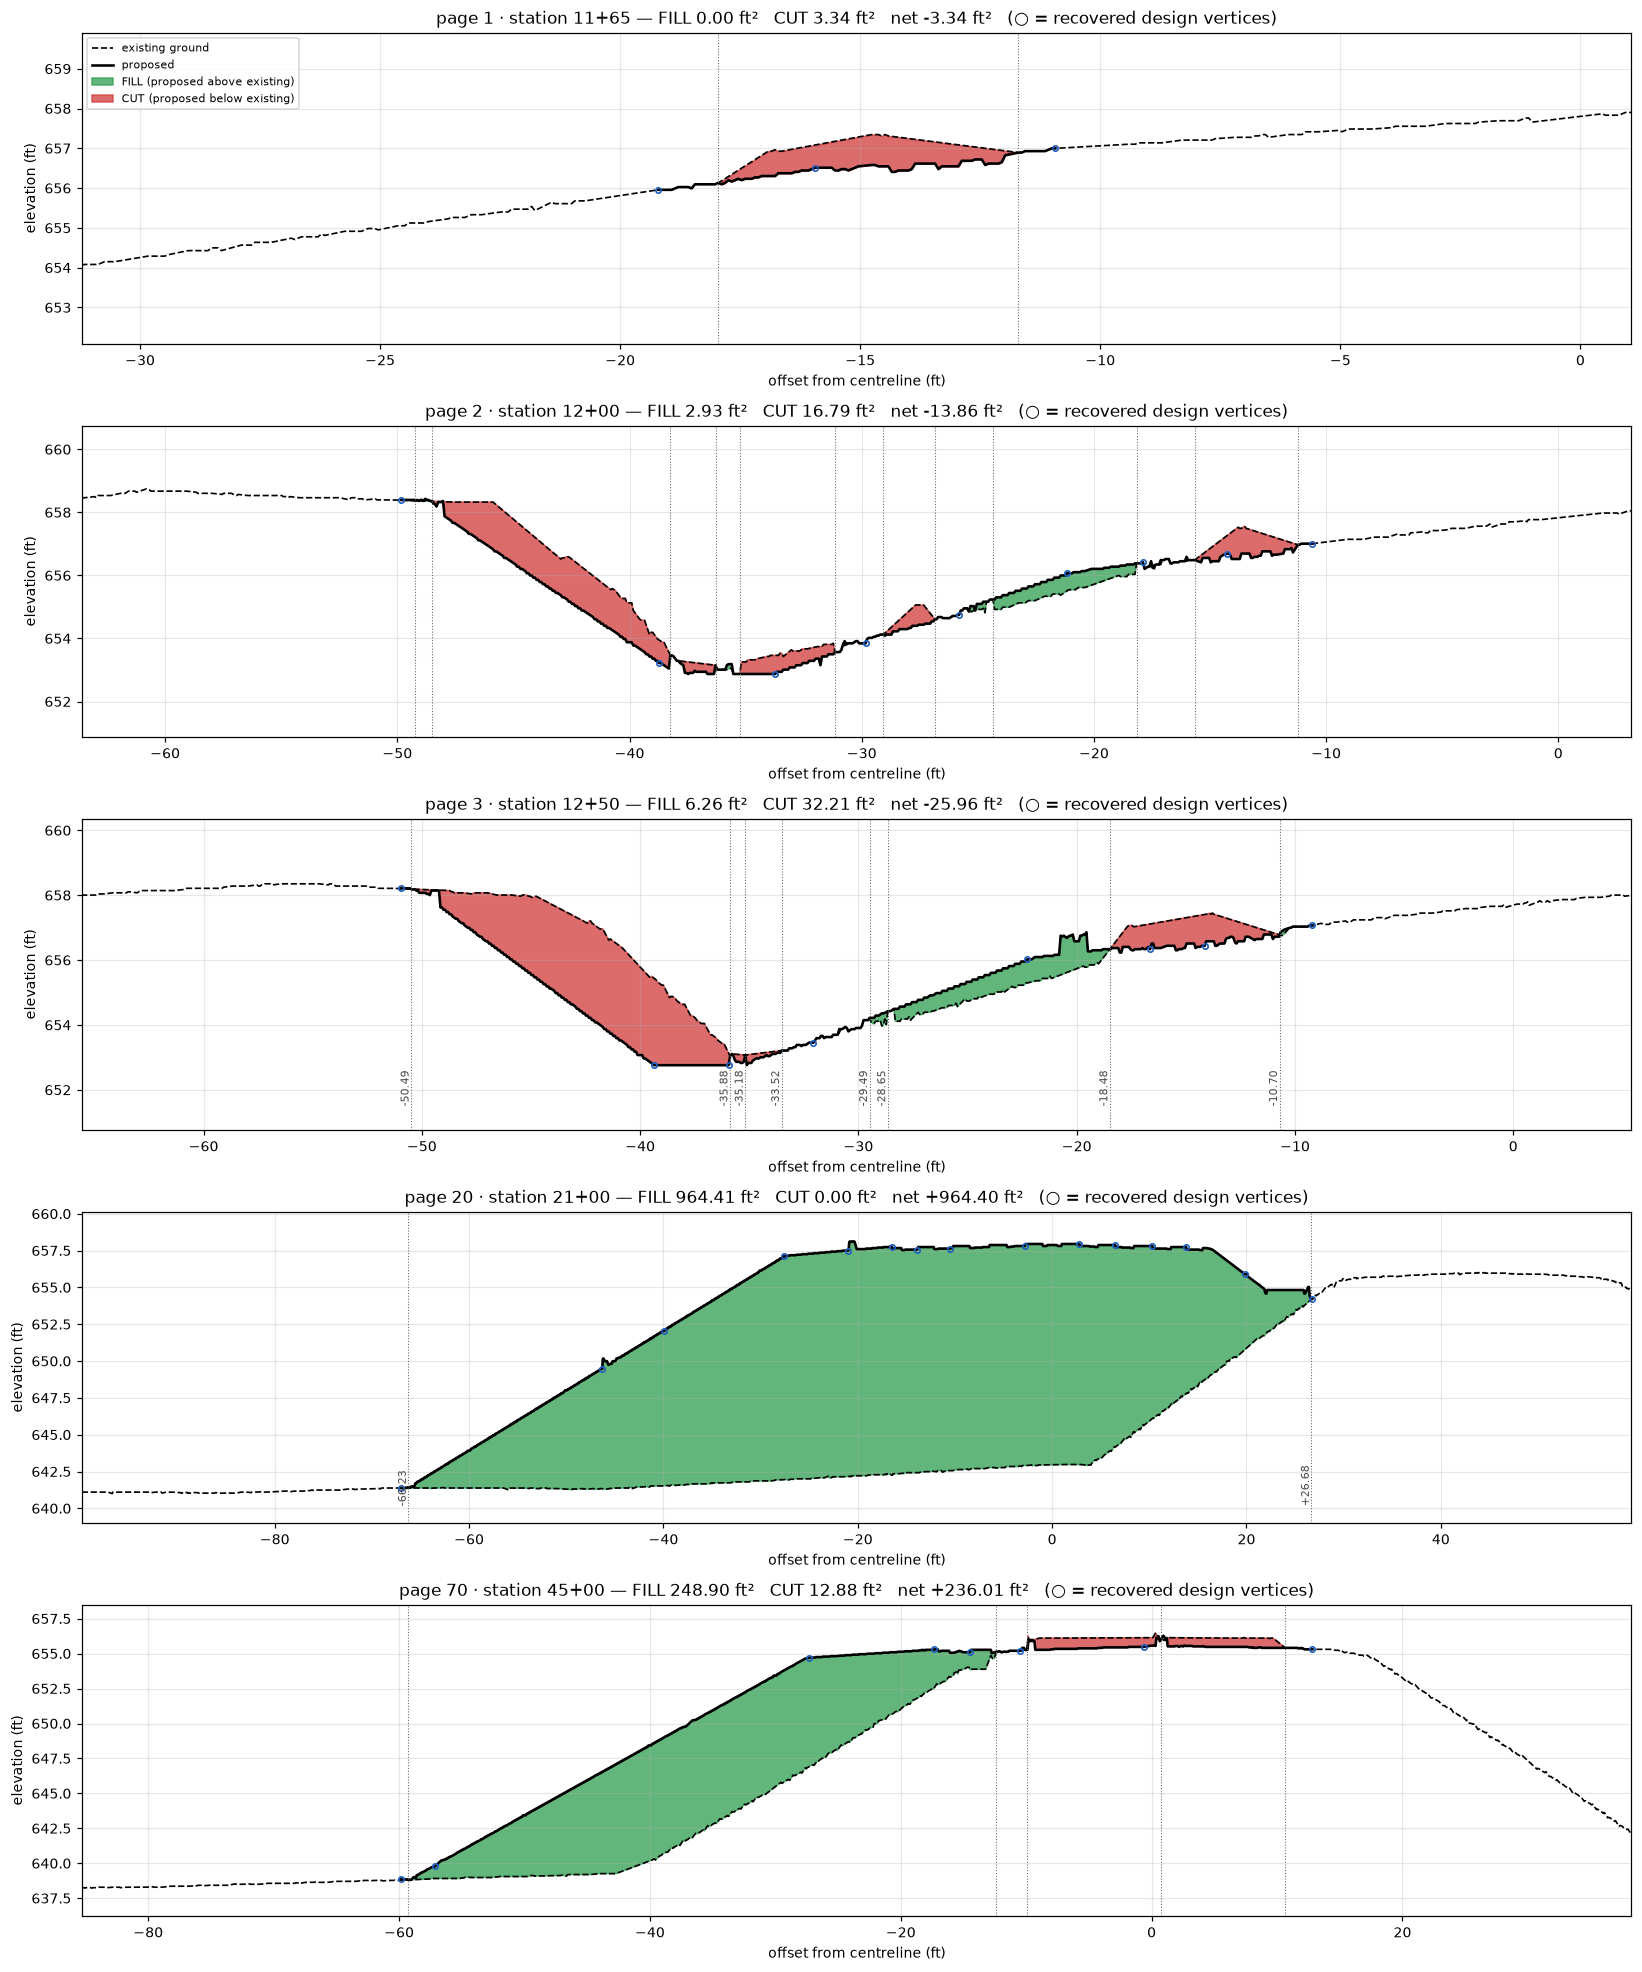

In [8]:
GREEN, RED = "#2e9e4f", "#d13b3b"

fig, axes = plt.subplots(len(SEC), 1, figsize=(15, 3.6*len(SEC)))
for ax, (p, s) in zip(np.atleast_1d(axes), SEC.items()):
    r = RES[p]
    ax.plot(s.x, s.ground, "k--", lw=1.1, label="existing ground")
    ax.plot(s.x, s.design, "k-",  lw=1.7, label="proposed")
    ax.fill_between(r["x"], r["g"], r["d"], where=r["d"] > r["g"], interpolate=True,
                    color=GREEN, alpha=.75, label="FILL (proposed above existing)")
    ax.fill_between(r["x"], r["g"], r["d"], where=r["d"] < r["g"], interpolate=True,
                    color=RED,   alpha=.75, label="CUT (proposed below existing)")
    for xc in r["cross_sig"]:
        ax.axvline(xc, color="0.4", lw=.7, ls=":")
        ax.annotate(f"{xc:+.2f}", (xc, ax.get_ylim()[0]), fontsize=7, rotation=90,
                    va="bottom", ha="right", color="0.3")
    V = POLY[p]; ax.plot(V[:, 0], V[:, 1], "o", ms=3.5, mfc="none", mec="#1f5fbf", mew=1.1)
    lo, hi = r["x"].min(), r["x"].max(); pad = max(12, .35*(hi-lo))
    ax.set_xlim(lo-pad, hi+pad)
    ins = (s.x > lo-pad) & (s.x < hi+pad)
    yy = np.concatenate([s.ground[ins], s.design[ins]]); yy = yy[~np.isnan(yy)]
    ax.set_ylim(yy.min()-2, yy.max()+2)
    ax.grid(alpha=.3); ax.set_xlabel("offset from centreline (ft)"); ax.set_ylabel("elevation (ft)")
    ax.set_title(f"page {p} · station {PRINTED[p]['station']} — "
                 f"FILL {r['fill']:.2f} ft²   CUT {r['cut']:.2f} ft²   "
                 f"net {r['fill']-r['cut']:+.2f} ft²   (○ = recovered design vertices)")
    if p == list(SEC)[0]: ax.legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.savefig(f"{OUT}/sections_vector.png", dpi=130); plt.show()

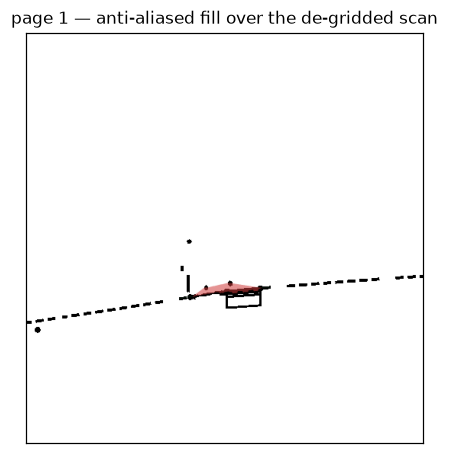

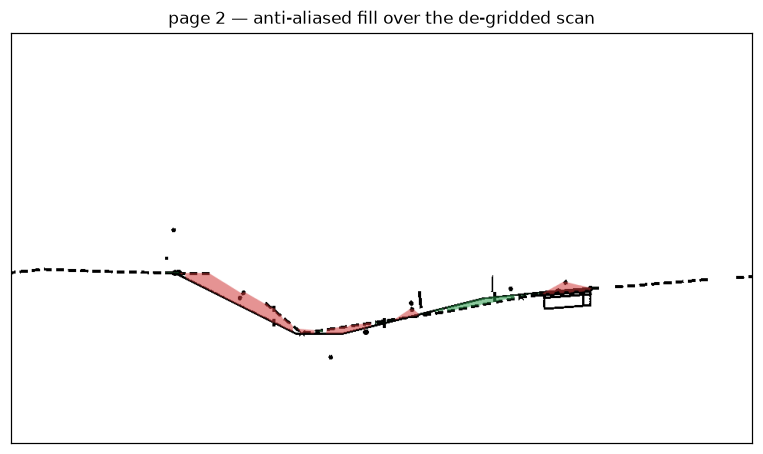

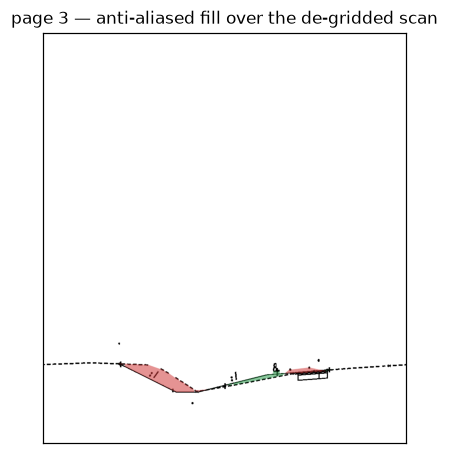

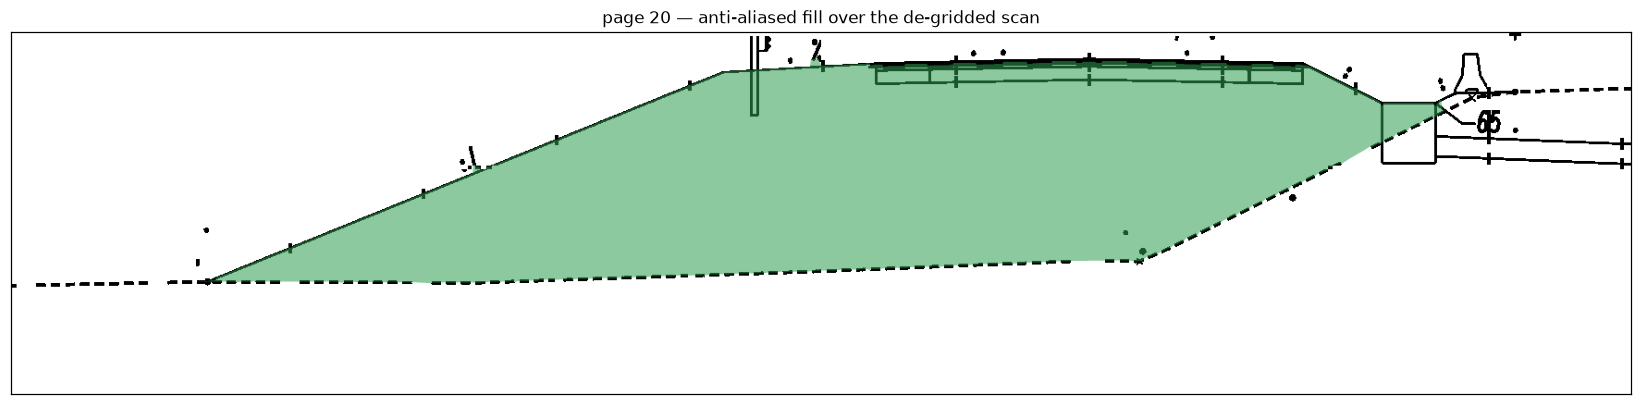

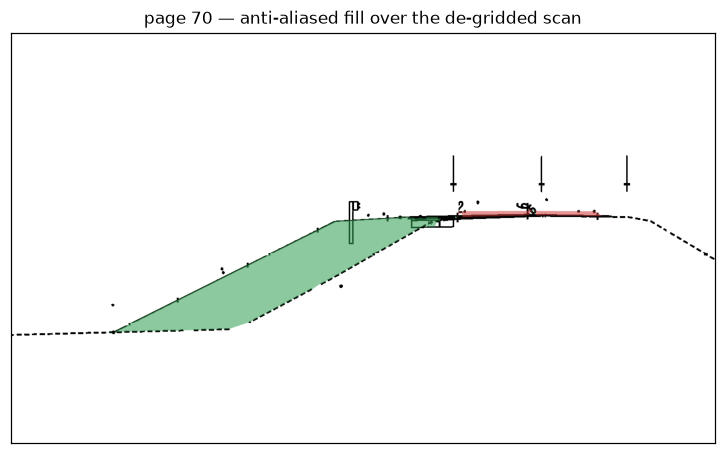

In [9]:
def overlay(s, res, ss=4, alpha=.55):
    """Anti-aliased polygon fill composited onto the de-gridded scan."""
    H, W = s.H, s.W
    acc = np.zeros((2, H*ss, W*ss), np.uint8)
    x, g, d = res["x"], res["g"], res["d"]
    xs = np.concatenate([[x[0]], res["cross"], [x[-1]]])
    for a, b in zip(xs[:-1], xs[1:]):
        if b-a <= 0: continue
        m = (x > a) & (x < b)
        xx = np.concatenate([[a], x[m], [b]])
        gg = np.interp(xx, x, g); dd = np.interp(xx, x, d)
        cols = (s.col_of(np.concatenate([xx, xx[::-1]]))*ss)
        rows = (s.row_of(np.concatenate([dd, gg[::-1]]))*ss)
        poly = np.stack([cols, rows], 1).astype(np.int32)
        k = 0 if np.interp(.5*(a+b), x, d-g) >= 0 else 1
        cv2.fillPoly(acc[k], [poly], 1)
    aa = [cv2.resize(a.astype(np.float32), (W, H), interpolation=cv2.INTER_AREA) for a in acc]
    base = cv2.cvtColor(255 - s.roi*255, cv2.COLOR_GRAY2BGR).astype(float)
    out = base.copy()
    for a, col in zip(aa, [(79, 158, 46), (59, 59, 209)]):
        w = (a*alpha)[..., None]
        out = out*(1-w) + np.array(col, float)*w
    return out.astype(np.uint8)

for p, s in SEC.items():
    img = overlay(s, RES[p]); cv2.imwrite(f"{OUT}/overlay_page{p:03d}.png", img)
    ov = np.where(s.overlap)[0]; pad = int(1.4*s.ppf*10)
    fig, ax = plt.subplots(figsize=(15, 4.2))
    ax.imshow(img[:, max(0, ov.min()-pad):min(s.W, ov.max()+pad)][:, :, ::-1])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"page {p} — anti-aliased fill over the de-gridded scan")
    plt.tight_layout(); plt.show()

In [10]:
rows = []
for p, s in SEC.items():
    r = RES[p]
    sigma = 0.5 / s.ppf
    width = r["x"].max() - r["x"].min()
    band  = 2*sigma*width
    tot   = r["fill"] + r["cut"]
    rows.append(dict(page=p, sigma_ft=round(sigma, 4), width_ft=round(width, 2),
                     total_ft2=round(tot, 3), band_ft2=round(band, 3),
                     band_pct=round(100*band/tot, 1) if tot else np.nan))
display(pd.DataFrame(rows).set_index("page"))

,sigma_ft,width_ft,total_ft2,band_ft2,band_pct
page,,,,,
1,0.0347,8.27,3.335,0.574,17.2
2,0.0347,39.25,19.718,2.726,13.8
3,0.0347,41.75,38.470,2.900,7.5
20,0.0347,93.77,964.408,6.514,0.7
70,0.0347,72.66,261.779,5.047,1.9


In [11]:
rows = []
for p, s in SEC.items():
    pr = PRINTED[p]; r = RES[p]
    c0 = int(round(s.col_of(0.0)))
    for key, arr, what in (("cl_design", s.design, "centreline PROPOSED elevation (ft)"),
                           ("cl_ground", s.ground, "centreline EXISTING elevation (ft)")):
        if pr[key] is not None and 0 <= c0 < s.W and not np.isnan(arr[c0]):
            rows.append(dict(page=p, quantity=what, printed=pr[key],
                             measured=round(float(arr[c0]), 2),
                             error=round(float(arr[c0]) - pr[key], 2)))
    if pr["invert"] is not None:
        rows.append(dict(page=p, quantity="ditch invert elevation (ft)",
                         printed=pr["invert"], measured=round(float(r["d"].min()), 2),
                         error=round(float(r["d"].min()) - pr["invert"], 2)))
    if pr["catch"] is not None:
        meas = float(POLY[p][0, 0])
        rows.append(dict(page=p, quantity="left catch point offset (ft)",
                         printed=pr["catch"], measured=round(meas, 2),
                         error=round(meas - pr["catch"], 2)))
VAL = pd.DataFrame(rows)
display(VAL)
ev = VAL[VAL.quantity.str.contains("elevation")]
print(f"elevation checks: {len(ev)} | median |error| {ev.error.abs().median():.2f} ft "
      f"| worst {ev.error.abs().max():.2f} ft")
print(ev.loc[ev.error.abs().idxmax()].to_dict())

,page,quantity,printed,measured,error
0,2,ditch invert elevation (ft),652.86,652.87,0.01
1,2,left catch point offset (ft),-49.01,-49.84,-0.83
2,3,ditch invert elevation (ft),652.73,652.76,0.03
3,3,left catch point offset (ft),-50.20,-50.95,-0.75
4,20,centreline PROPOSED elevation (ft),658.14,657.88,-0.26
5,20,centreline EXISTING elevation (ft),642.99,642.96,-0.03
6,20,left catch point offset (ft),-66.22,-67.00,-0.78
7,70,centreline PROPOSED elevation (ft),655.68,655.57,-0.11
8,70,centreline EXISTING elevation (ft),655.41,656.14,0.73
9,70,left catch point offset (ft),-59.20,-59.84,-0.64


elevation checks: 6 | median |error| 0.07 ft | worst 0.73 ft
{'page': 70, 'quantity': 'centreline EXISTING elevation (ft)', 'printed': 655.41, 'measured': 656.14, 'error': 0.73}


In [12]:
try:
    A1 = pd.read_csv("../Approach 1/outputs/totals_approach1.csv").set_index("page")
    cmp_ = pd.DataFrame({
        "A1_fill": A1.fill_ft2, "A2_fill": TOT2.fill_ft2,
        "A1_cut":  A1.cut_ft2,  "A2_cut":  TOT2.cut_ft2,
    })
    cmp_["d_fill_%"] = 100*(cmp_.A2_fill-cmp_.A1_fill)/cmp_.A2_fill.replace(0, np.nan)
    cmp_["d_cut_%"]  = 100*(cmp_.A2_cut -cmp_.A1_cut )/cmp_.A2_cut.replace(0, np.nan)
    display(cmp_.round(3))
    print("Approach 1 was run at its default cell size / supersampling; the residual is "
          "its quantisation error, and it shrinks as those are tightened.")
except FileNotFoundError:
    print("Run the Approach 1 notebook first to enable this comparison.")

,A1_fill,A2_fill,A1_cut,A2_cut,d_fill_%,d_cut_%
page,,,,,,
1,0.000,0.000,3.300,3.335,NaN,1.056
2,2.956,2.928,16.697,16.790,-0.946,0.555
3,6.290,6.257,32.080,32.213,-0.522,0.412
20,964.590,964.405,0.002,0.002,-0.019,14.082
70,249.018,248.897,12.752,12.882,-0.049,1.012


Approach 1 was run at its default cell size / supersampling; the residual is its quantisation error, and it shrinks as those are tightened.
